In [21]:
# Import delle librerie necessarie
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Silenziare i warning
warnings.filterwarnings('ignore')

SEED=2024

In [22]:
# Scelta di un dataset per classificazione binaria: Breast Cancer Wisconsin Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Data preprocessing
# Nel dataset Breast Cancer Wisconsin, le features sono già numeriche, quindi possiamo procedere direttamente allo split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [23]:
# Train di un modello lineare: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(xtrain, ytrain)

# Calcolo dell'accuratezza di addestramento e test per la Logistic Regression
test_accuracy_lr = accuracy_score(ytest, lr_model.predict(xtest))
print(f"Accuratezza di test (Logistic Regression): {test_accuracy_lr}")

Accuratezza di test (Logistic Regression): 0.9298245614035088


Output modello non standardizzato

Coefficienti Logistic Regression:
mean radius: 2.4242515550630754
worst concave points: -1.1855120114552928
worst concavity: -1.0703944190742407
mean concavity: -0.8093320097247924
worst radius: 0.6827703504052871
texture error: 0.679149430069835
perimeter error: 0.6703394880406168
mean concave points: -0.6370872239702934
worst symmetry: -0.6161313730280863
worst smoothness: -0.5392734744798814


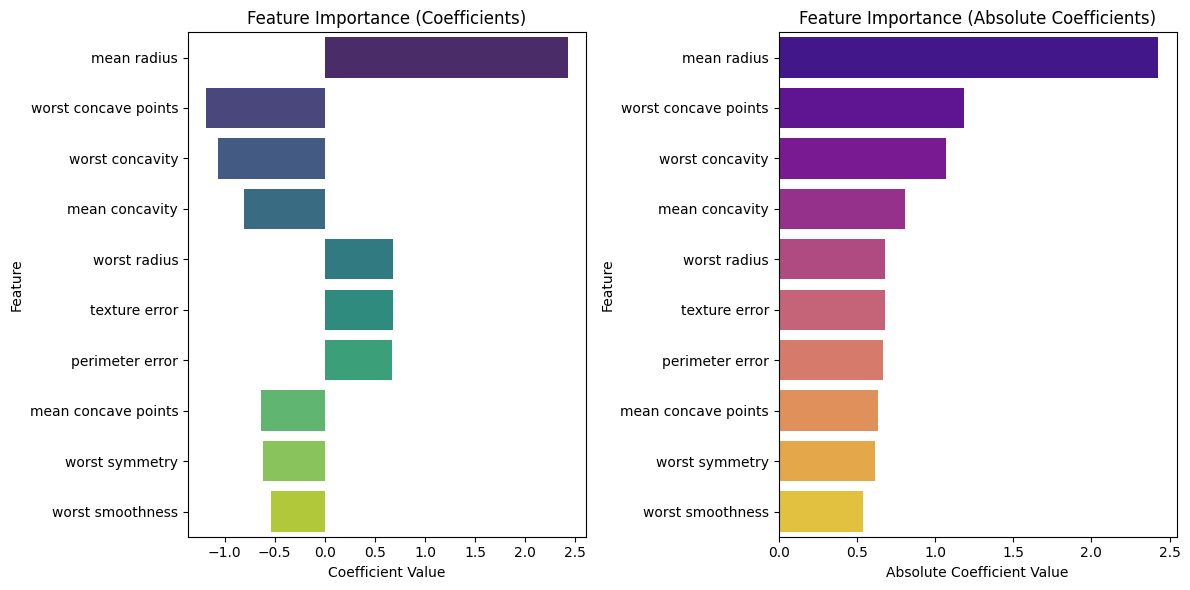

In [24]:
# Stampa dei coefficienti appaiati ai nomi delle variabili
print("Coefficienti Logistic Regression:")
sorted_features = sorted(zip(data.feature_names, lr_model.coef_[0]), key=lambda x: abs(x[1]), reverse=True)[:10]
for feature, coef in sorted_features:
    print(f"{feature}: {coef}")

# Separazione delle feature names, coefficienti e valori assoluti
features = [feature for feature, coef in sorted_features]
coefs = [coef for feature, coef in sorted_features]
abs_coefs = [abs(coef) for coef in coefs]

# Creazione del grafico a barre
plt.figure(figsize=(12, 6))

# Grafico dei coefficienti
plt.subplot(1, 2, 1)
sns.barplot(x=coefs, y=features, palette="viridis")
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

# Grafico dei valori assoluti dei coefficienti
plt.subplot(1, 2, 2)
sns.barplot(x=abs_coefs, y=features, palette="plasma")
plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Standardizziamo

In [25]:
# Import delle librerie necessarie
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

# Silenziare i warning
warnings.filterwarnings('ignore')

# Definizione del seed per la riproducibilità
SEED = 2024

# Scelta di un dataset per classificazione binaria: Breast Cancer Wisconsin Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Standardizzazione delle features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Data preprocessing: Split dei dati in training e test set
xtrain, xtest, ytrain, ytest = train_test_split(X_standardized, y, test_size=0.2, random_state=SEED)

# Train di un modello lineare: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(xtrain, ytrain)

# Calcolo dell'accuratezza di addestramento e test per la Logistic Regression
test_accuracy_lr = accuracy_score(ytest, lr_model.predict(xtest))
print(f"Accuratezza di test (Logistic Regression): {test_accuracy_lr}")


Accuratezza di test (Logistic Regression): 0.9824561403508771


Coefficienti Logistic Regression:
worst texture: -1.3237474339423643
radius error: -1.2647607748465817
worst radius: -1.0204627314863843
worst area: -0.9337810544522734
mean concave points: -0.918257713280321
area error: -0.8592547273977749
worst concavity: -0.8547302102563069
mean concavity: -0.8419406178963909
worst concave points: -0.8414881985047611
worst symmetry: -0.7733713450642908


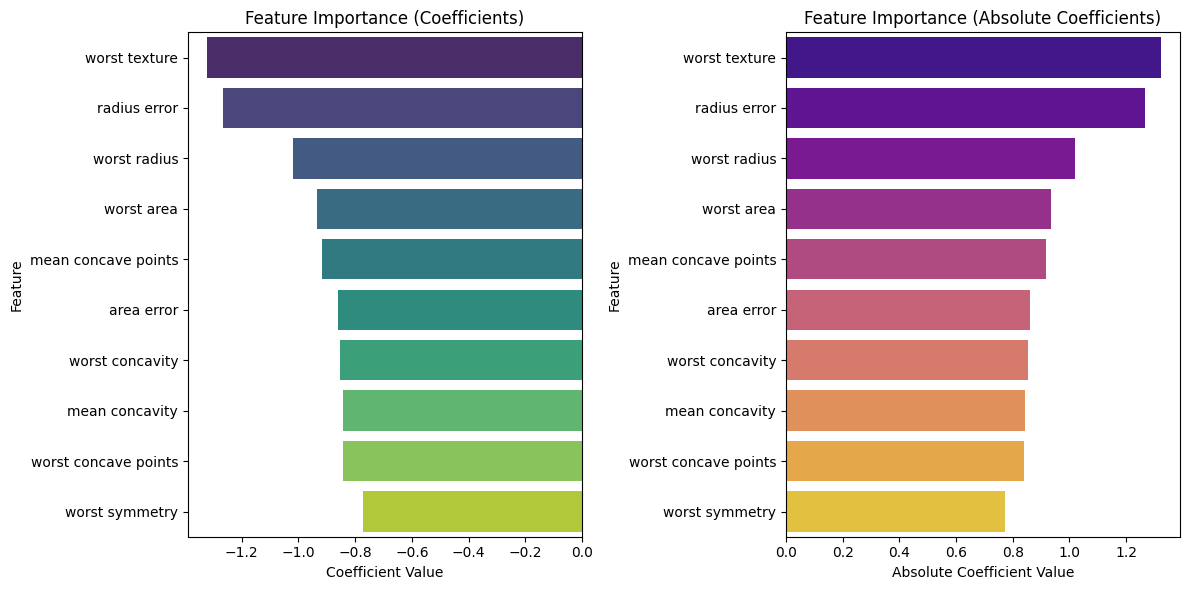

In [26]:
# Stampa dei coefficienti appaiati ai nomi delle variabili
print("Coefficienti Logistic Regression:")
sorted_features = sorted(zip(data.feature_names, lr_model.coef_[0]), key=lambda x: abs(x[1]), reverse=True)[:10]
for feature, coef in sorted_features:
    print(f"{feature}: {coef}")

# Separazione delle feature names, coefficienti e valori assoluti
features = [feature for feature, coef in sorted_features]
coefs = [coef for feature, coef in sorted_features]
abs_coefs = [abs(coef) for coef in coefs]

# Creazione del grafico a barre
plt.figure(figsize=(12, 6))

# Grafico dei coefficienti
plt.subplot(1, 2, 1)
sns.barplot(x=coefs, y=features, palette="viridis")
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

# Grafico dei valori assoluti dei coefficienti
plt.subplot(1, 2, 2)
sns.barplot(x=abs_coefs, y=features, palette="plasma")
plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Spiegazione locale per l'istanza 1 (etichetta vera: 0)
Intercept: 0.2029779903645536
mean radius: 1.1879485242391545 * -0.23812396551024217 = -0.2828790134138675
mean texture: 0.3002734542913885 * -0.45189888853988297 = -0.13569324025230983
mean perimeter: 1.1875532876625208 * -0.24206476626450285 = -0.28746480900467003
mean area: 1.1294241380988297 * -0.33400340174069654 = -0.37723150413306333
mean smoothness: 0.7429472026036915 * -0.01413293782499465 = -0.010500026621651675
mean compactness: 0.3877286170243026 * 0.3909177693889061 = 0.15157000609538582
mean concavity: 0.8550021219397657 * -0.8419406178963909 = -0.7198610148486916
mean concave points: 1.1759696857604847 * -0.918257713280321 = -1.0798432345334004
mean symmetry: 0.17663764640972213 * 0.30852949145060604 = 0.054497923217823534
mean fractal dimension: -0.48022894570476987 * 0.24809130910814323 = -0.1191406278115198
radius error: 0.5043074947041366 * -1.2647607748465817 = -0.6378283377629422
texture error: -0.5340583440354

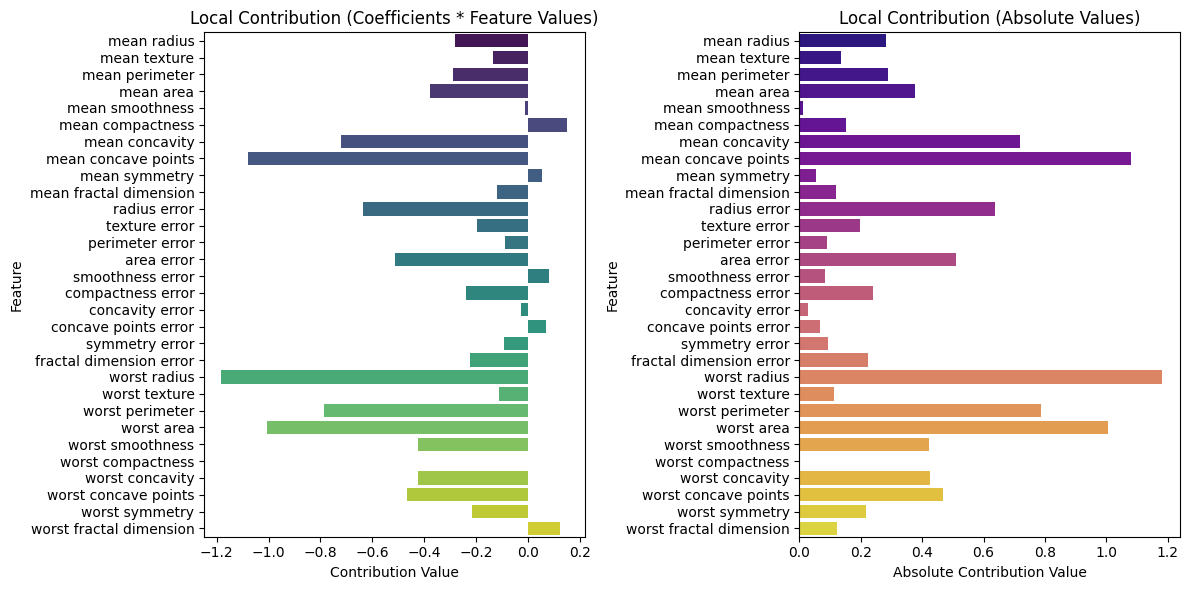

In [27]:
# Selezioniamo un'istanza specifica per la spiegazione locale
instance_index = 1  # ad esempio, seconda istanza del set di test
instance = xtest[instance_index]
true_label = ytest[instance_index]

# Utilità per spiegazioni locali su Logistic Regression
def explain_lr_local(model, instance, feature_names):
    contributions = []
    explanation = f"Intercept: {model.intercept_[0]}\n"
    for name, value, coef in zip(feature_names, instance, model.coef_[0]):
        contribution = value * coef
        contributions.append((name, value, coef, contribution))
        explanation += f"{name}: {value} * {coef} = {contribution}\n"
    return explanation, contributions

# Spiegazione locale per Logistic Regression
print(f"Spiegazione locale per l'istanza {instance_index} (etichetta vera: {true_label})")
explanation, contributions = explain_lr_local(lr_model, instance, data.feature_names)
print(explanation)

# Preparazione dei dati per il grafico
features = [name for name, value, coef, contribution in contributions]
contrib_values = [contribution for name, value, coef, contribution in contributions]
abs_contrib_values = [abs(contribution) for contribution in contrib_values]

# Creazione del grafico a barre
plt.figure(figsize=(12, 6))

# Grafico dei contributi locali
plt.subplot(1, 2, 1)
sns.barplot(x=contrib_values, y=features, palette="viridis")
plt.title("Local Contribution (Coefficients * Feature Values)")
plt.xlabel("Contribution Value")
plt.ylabel("Feature")

# Grafico dei valori assoluti dei contributi locali
plt.subplot(1, 2, 2)
sns.barplot(x=abs_contrib_values, y=features, palette="plasma")
plt.title("Local Contribution (Absolute Values)")
plt.xlabel("Absolute Contribution Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [28]:
valori_datapoint = xtest[instance_index]
somma_pesata = np.dot(valori_datapoint,lr_model.coef_[0])+lr_model.intercept_[0]
post_logistica = 1 / (1 + np.exp(-somma_pesata))
vettore_risultato = [1-post_logistica,post_logistica]
print(vettore_risultato)
print(lr_model.predict_proba([valori_datapoint])[0])

[0.9998723625150349, 0.00012763748496509637]
[9.99872363e-01 1.27637485e-04]


In [29]:
# Train di un Decision Tree
dt_model = DecisionTreeClassifier(random_state=SEED)
dt_model.fit(xtrain, ytrain)

# Calcolo dell'accuratezza di addestramento e test per il Decision Tree
test_accuracy_dt = accuracy_score(ytest, dt_model.predict(xtest))
print(f"Accuratezza di test (Decision Tree): {test_accuracy_dt}")

Accuratezza di test (Decision Tree): 0.956140350877193


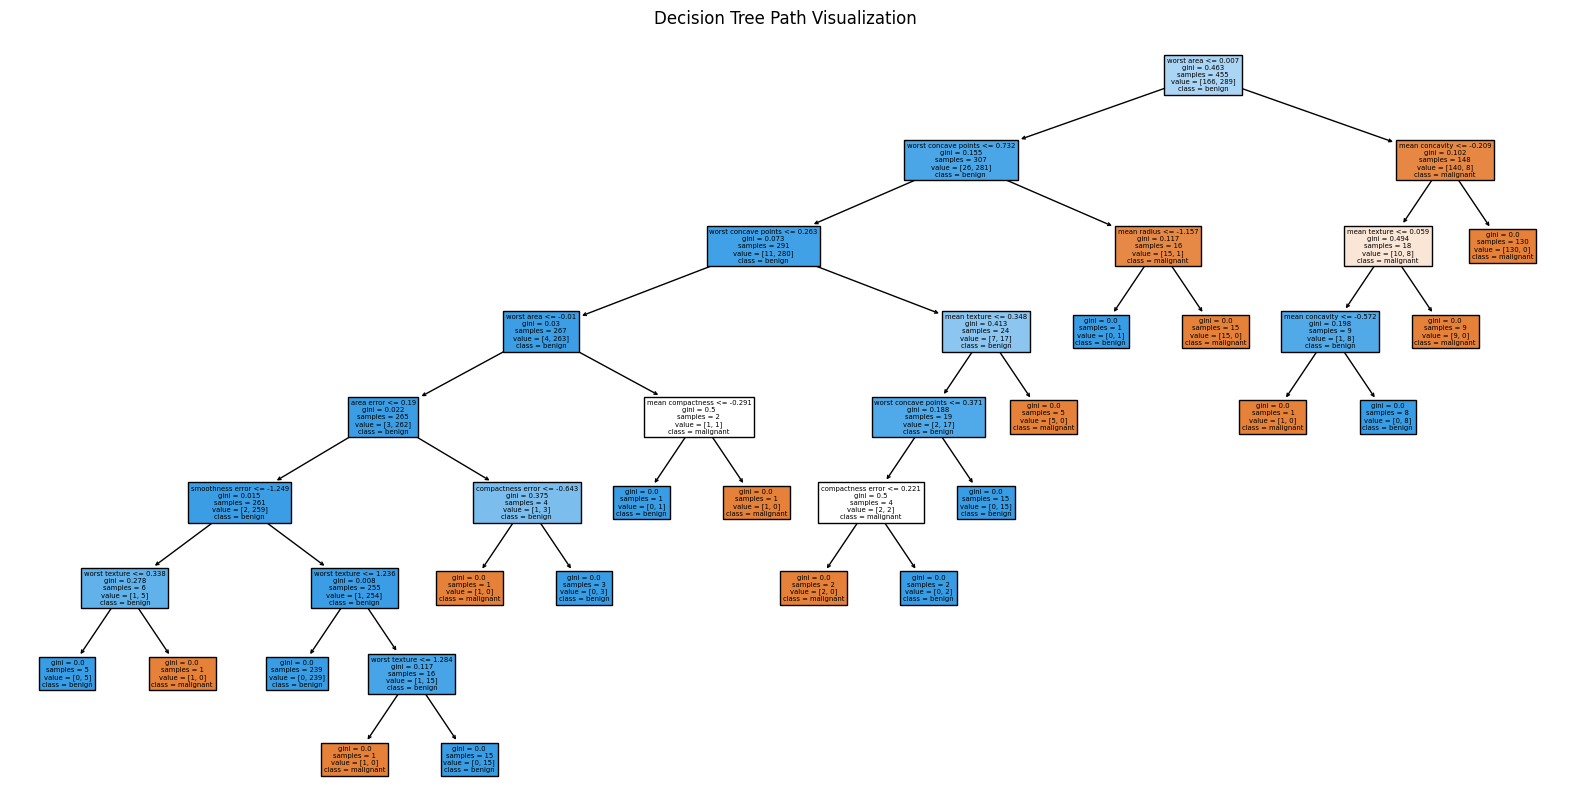

In [30]:
# Visualizzazione del path nell'albero
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.title("Decision Tree Path Visualization")
plt.show()

In [31]:
# Funzione per tracciare il percorso locale nell'albero decisionale
def plot_dt_path(dt_model, instance, feature_names):
    node_indicator = dt_model.decision_path([instance])
    leaf_id = dt_model.apply([instance])

    # Ottieni il percorso percorso dall'istanza
    node_index = node_indicator.indices[node_indicator.indptr[0]: node_indicator.indptr[1]]

    print(f"Percorso nell'albero per l'istanza {instance_index} (etichetta vera: {true_label}):")
    for node_id in node_index:
        # Verifica se siamo a una foglia
        if leaf_id == node_id:
            print(f"-> foglia {node_id}, etichetta predetta: {dt_model.classes_[dt_model.tree_.value[node_id].argmax()]}")
        else:
            # Decisione presa al nodo
            if instance[dt_model.tree_.feature[node_id]] <= dt_model.tree_.threshold[node_id]:
                threshold_sign = "<="
            else:
                threshold_sign = ">"
            print(f"-> nodo {node_id}, {feature_names[dt_model.tree_.feature[node_id]]} {threshold_sign} {dt_model.tree_.threshold[node_id]}")

# Traccia il percorso per l'istanza selezionata nel Decision Tree
plot_dt_path(dt_model, instance, data.feature_names)


Percorso nell'albero per l'istanza 1 (etichetta vera: 0):
-> nodo 0, worst area > 0.006973414201638661
-> nodo 30, mean concavity > -0.20915722846984863
-> foglia 36, etichetta predetta: 0
